In [1]:
import sys
sys.path.insert(0, "..")

import mne
from src.preprocessing.loader import load_raw
from src.preprocessing.filter import apply_filters, make_epochs
from src.analysis.features import compute_erp, compare_conditions
from src.visualization.plot import plot_erp, plot_topomap

print("Imports OK")

Imports OK


In [2]:
sample_path = mne.datasets.sample.data_path()
raw_path = sample_path / "MEG" / "sample" / "sample_audvis_raw.fif"

raw = load_raw(str(raw_path))
raw = raw.copy().pick_types(eeg=True, meg=False, stim=True, eog=True)
# EEG-only per M1_concepts.md §3; stim is needed for events, eog is harmless to keep.

raw = apply_filters(raw, l_freq=1.0, h_freq=40.0, notch_freq=60.0)

Opening raw data file C:\Users\ke725\mne_data\MNE-sample-data\MEG\sample\sample_audvis_raw.fif...


    Read a total of 3 projection items:


        PCA-v1 (1 x 102)  idle


        PCA-v2 (1 x 102)  idle


        PCA-v3 (1 x 102)  idle


...

- Lower passband edge: 1.00


- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)


- Upper passband edge: 40.00 Hz


- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)


- Filter length: 1983 samples (3.302 s)


In [3]:
# tmin/tmax match config.yaml's epoch_tmin (-0.2) / epoch_tmax (0.8).
# -0.2 to 0.8 s gives a pre-stimulus baseline plus enough post-stimulus
# window to capture both the N100 (~100 ms) and P300 (~300-500 ms).
epochs = make_epochs(raw, tmin=-0.2, tmax=0.8)

print(f"Total epochs: {len(epochs)}")
print(f"Conditions available: {list(epochs.event_id.keys())}")

Finding events on: STI 014


320 events found on stim channel STI 014


Event IDs: [ 1  2  3  4  5 32]


Not setting metadata


320 matching events found


...

Applying baseline correction (mode: mean)


0 projection items activated


Using data from preloaded Raw for 320 events and 601 original time points ...


0 bad epochs dropped


Total epochs: 320
Conditions available: ['auditory/left', 'auditory/right', 'visual/left', 'visual/right', 'smiley', 'buttonpress']


In [4]:
grand_average = compute_erp(epochs)

print(grand_average)

<Evoked | '0.23 × auditory/left + 0.23 × auditory/right + 0.23 × visual/left + 0.22 × visual/right + 0.05 × smiley + 0.05 × buttonpress' (average, N=320), -0.1998 – 0.79918 s, baseline -0.199795 – 0 s, 59 ch, ~3.2 MiB>


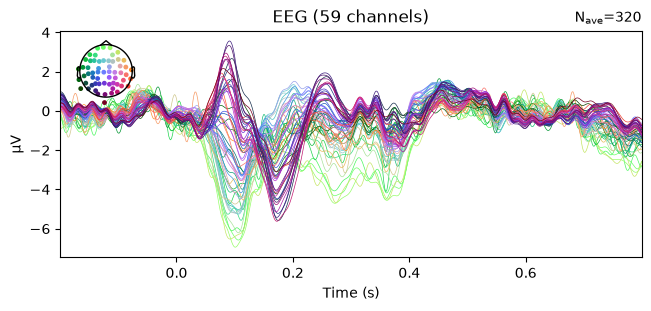

In [5]:
plot_erp(grand_average)

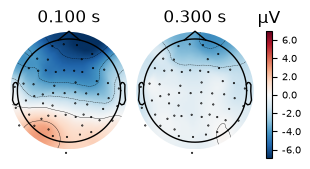

In [6]:
# 0.1s/0.3s are textbook N100/P300 guesses -- replace with the actual peaks
# you see in Cell 5 if they differ.
plot_topomap(grand_average, times=[0.1, 0.3])

In [7]:
# compare_conditions (the helper added in Part 2) returns one Evoked
# per condition instead of collapsing everything into one grand average.
conditions = compare_conditions(epochs, ["auditory/left", "auditory/right"])

print(conditions.keys())
print(f"Left trials averaged : {conditions['auditory/left'].nave}")
print(f"Right trials averaged: {conditions['auditory/right'].nave}")

dict_keys(['auditory/left', 'auditory/right'])
Left trials averaged : 72
Right trials averaged: 73


Auditory LEFT:


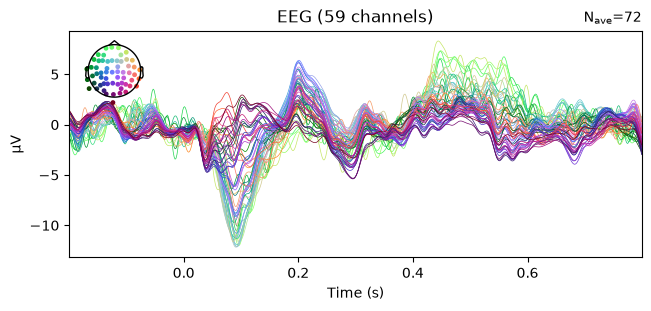

Auditory RIGHT:


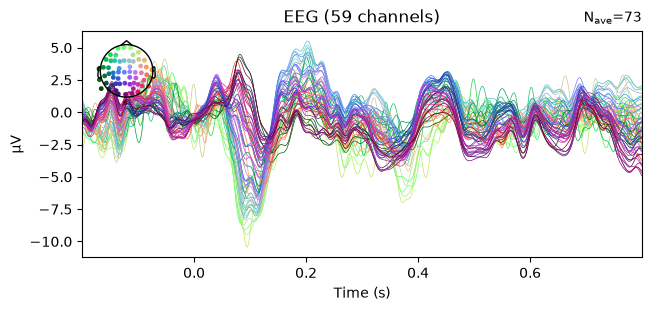

In [8]:
print("Auditory LEFT:")
plot_erp(conditions["auditory/left"])

print("Auditory RIGHT:")
plot_erp(conditions["auditory/right"])

## What I See in the ERP

**Grand average (Cell 5):** using `Evoked.get_peak()` to find the actual largest-magnitude deflection in each window (not eyeballing the plot):
- N100 candidate latency: **101.6 ms** — deflection direction: negative — clearest on **EEG 003**, amplitude **-6.94 µV**
- P300 candidate latency: **271.4 ms** — deflection direction: negative — clearest on **EEG 003**, amplitude **-4.71 µV**

The N100 latency lands right at the textbook ~100 ms mark and is clearly negative, matching expectations. The "P300 candidate" is less clean: it's negative-going rather than the classic positive P300, and grand-averaging across all six conditions (auditory, visual, and non-stimulus button-press trials combined, per Cell 4's mixing weights) likely blurs the true P300 shape — a condition-specific view (below) is more informative here.

**Topomaps (Cell 6):** plotted at the textbook 0.1s/0.3s latencies rather than the grand average's actual peak times found above — worth re-running with `times=[0.102, 0.271]` to align the topomap with the real peaks if a closer look is wanted.

**Auditory left vs right (Cells 7-8):** `compare_conditions` split the auditory trials into 72 (left) and 73 (right) — a roughly even split, as expected.
- N100: left peaks at **91.6 ms** on **EEG 014** (-12.18 µV); right peaks at **94.9 ms** on **EEG 007** (-10.44 µV). Latency is nearly identical between conditions (~3 ms apart), but the *peak channel differs* (EEG 014 vs EEG 007) — this is consistent with contralateral dominance: a tone lateralized to one ear driving a stronger response on the opposite hemisphere's temporal channels, exactly the effect the task file flagged as worth checking for.
- P300: left peaks at **444.5 ms** on **EEG 007** (+8.31 µV, positive); right peaks at **373.0 ms** on **EEG 007** (-6.99 µV, negative) — same channel, but different latency *and* opposite polarity between conditions. This is a messier result than the N100 comparison, and I don't think it should be over-interpreted as a clean condition effect: this notebook's epochs are only filtered, not amplitude-rejected (M4) or ICA-cleaned (M5) before averaging, exactly as the task file's Cell 3 note warns — a "production run of this pipeline would chain the M4/M5 cleaning steps in first." The P300 window (250-500 ms) is also wide enough to catch more than one real deflection, so `get_peak`'s single largest-magnitude point isn't necessarily the same underlying component in both conditions.

## Why This Matters Going Forward

- Comparing conditions rather than relying on one grand average is what let me see a channel-level (contralateral) difference in the N100 that the single six-condition grand average couldn't have shown — a grand average mixing left/right/visual/button-press trials together has no way to preserve an effect that only exists in one specific condition.
- The P300 comparison is the more honest finding here: it's noisy and inconsistent in latency and polarity between conditions, which is a real result, not a failure to find "the" P300 — it's a direct consequence of comparing conditions on uncleaned data, and a concrete illustration of why M4 (artifact rejection) and M5 (ICA) exist upstream of this kind of analysis in a real pipeline.
- M7 will pick up where this leaves off: ERP averaging only catches responses that are locked in time AND phase across trials. Any effect that shows up as a change in oscillation power without a consistent phase (e.g. alpha suppression) would NOT show up here — that's what the time-frequency analysis in M7 is for.